## GARCH Volatility Modelling

**Load the series and compute daily log-returns**

Log-returns shape: (638,)
count    638.000000
mean       0.000379
std        0.060268
min       -0.299201
25%       -0.029323
50%       -0.000210
75%        0.031840
max        0.258833
Name: consumption_kwh, dtype: float64


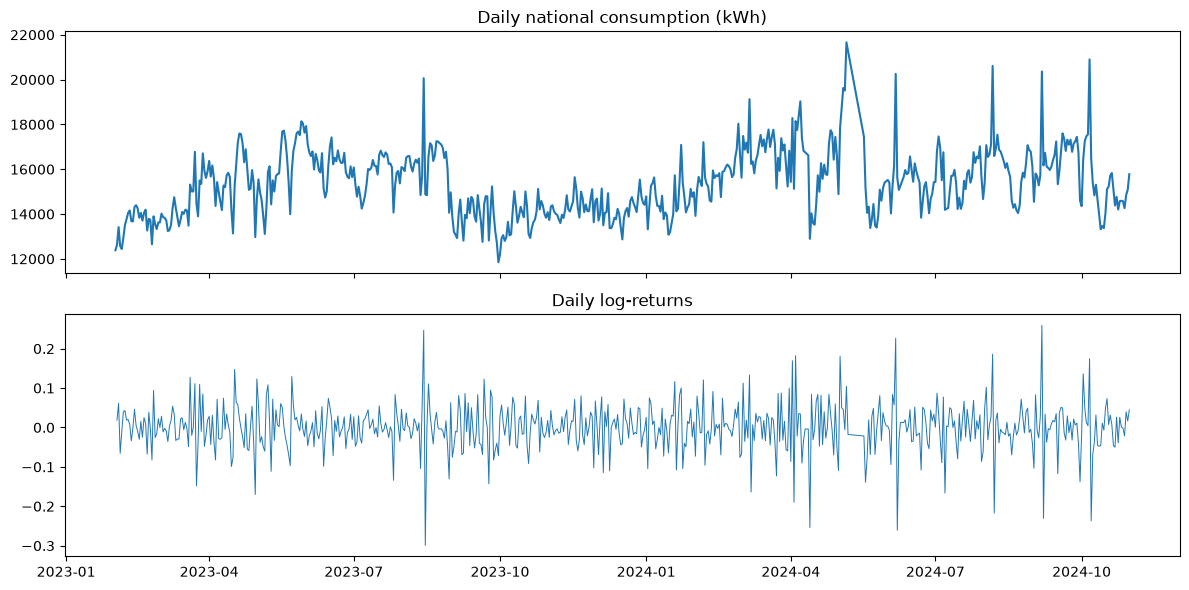

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

features = pd.read_parquet("../outputs/features/daily_consumption_engineered.parquet")
consumption = features["consumption_kwh"]

log_returns = np.log(consumption / consumption.shift(1)).dropna()

print("Log-returns shape:", log_returns.shape)
print(log_returns.describe())

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axes[0].plot(consumption.index, consumption.values)
axes[0].set_title("Daily national consumption (kWh)")
axes[1].plot(log_returns.index, log_returns.values, linewidth=0.7)
axes[1].set_title("Daily log-returns")
plt.tight_layout()
plt.show()

**Test for ARCH effects before fitting anything**

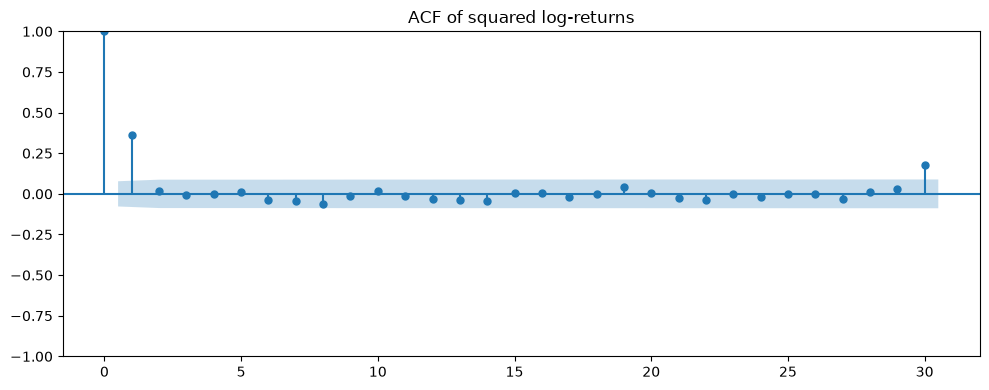

Ljung-Box on squared returns:
      lb_stat     lb_pvalue
5   85.771796  5.185926e-17
10  90.820573  3.681734e-15
20  94.907283  1.015448e-11

ARCH-LM test: statistic=99.2304, p-value=0.000000


In [2]:
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from statsmodels.graphics.tsaplots import plot_acf

squared_returns = log_returns ** 2

fig, ax = plt.subplots(figsize=(10, 4))
plot_acf(squared_returns, lags=30, ax=ax)
ax.set_title("ACF of squared log-returns")
plt.tight_layout()
plt.show()

lb_squared = acorr_ljungbox(squared_returns, lags=[5, 10, 20], return_df=True)
print("Ljung-Box on squared returns:")
print(lb_squared)

arch_stat, arch_p, _, _ = het_arch(log_returns, nlags=10)
print(f"\nARCH-LM test: statistic={arch_stat:.4f}, p-value={arch_p:.6f}")


**Fit GARCH(1,1)**

In [3]:
from arch import arch_model

returns_pct = log_returns * 100  # arch package convention — improves numerical stability

garch = arch_model(returns_pct, vol="Garch", p=1, q=1, mean="Constant", dist="normal")
garch_fit = garch.fit(disp="off")

print(garch_fit.summary())


                     Constant Mean - GARCH Model Results                      
Dep. Variable:        consumption_kwh   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -2004.53
Distribution:                  Normal   AIC:                           4017.06
Method:            Maximum Likelihood   BIC:                           4034.89
                                        No. Observations:                  638
Date:                Sat, Jul 11 2026   Df Residuals:                      637
Time:                        09:15:54   Df Model:                            1
                               Mean Model                               
                 coef    std err          t      P>|t|  95.0% Conf. Int.
------------------------------------------------------------------------
mu             0.0871      0.187      0.466      0.641 [ -0.279,  0.45

**Extract conditional volatility and check whether the model removed the remaining ARCH effects**

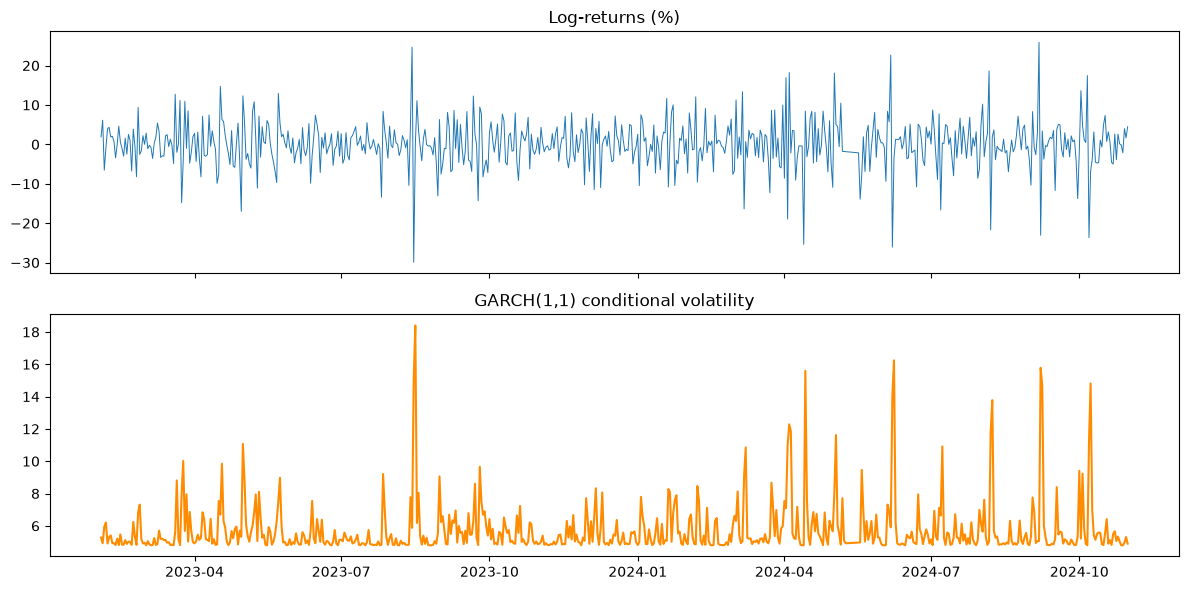

Ljung-Box on squared standardized residuals (should now be non-significant if model fits well):
      lb_stat  lb_pvalue
5    1.904234   0.862231
10   6.577800   0.764611
20  12.929824   0.880375


In [4]:
conditional_vol = garch_fit.conditional_volatility

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axes[0].plot(log_returns.index, returns_pct.values, linewidth=0.7)
axes[0].set_title("Log-returns (%)")
axes[1].plot(log_returns.index, conditional_vol.values, color="darkorange")
axes[1].set_title("GARCH(1,1) conditional volatility")
plt.tight_layout()
plt.show()

standardized_resid = garch_fit.std_resid
lb_std_resid_sq = acorr_ljungbox(standardized_resid**2, lags=[5, 10, 20], return_df=True)
print("Ljung-Box on squared standardized residuals (should now be non-significant if model fits well):")
print(lb_std_resid_sq)


**Cross-reference volatility against tariff-revision dates**

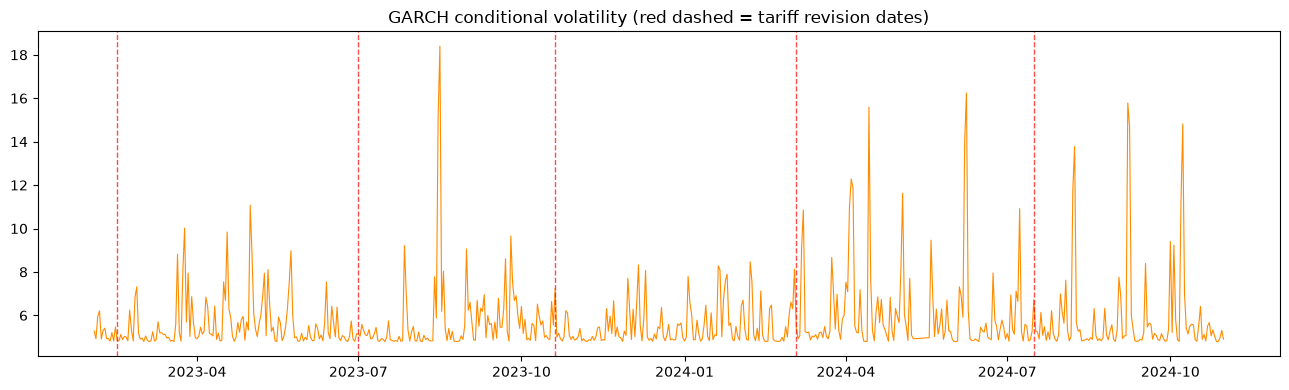

2023-02-15: window mean vol = 4.99 (overall mean = 5.76)
2023-07-01: window mean vol = 5.17 (overall mean = 5.76)
2023-10-20: window mean vol = 5.39 (overall mean = 5.76)
2024-03-04: window mean vol = 6.61 (overall mean = 5.76)
2024-07-16: window mean vol = 5.40 (overall mean = 5.76)


In [5]:
TARIFF_REVISION_DATES = pd.to_datetime([
    "2023-02-15", "2023-07-01", "2023-10-20", "2024-03-04", "2024-07-16",
])

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(conditional_vol.index, conditional_vol.values, color="darkorange", linewidth=0.8)
for d in TARIFF_REVISION_DATES:
    ax.axvline(d, color="red", linestyle="--", linewidth=1, alpha=0.7)
ax.set_title("GARCH conditional volatility (red dashed = tariff revision dates)")
plt.tight_layout()
plt.show()

# Quantify: average volatility in a +/-5 day window around each revision vs overall average
overall_mean_vol = conditional_vol.mean()
for d in TARIFF_REVISION_DATES:
    window = conditional_vol.loc[d - pd.Timedelta(days=5): d + pd.Timedelta(days=5)]
    print(f"{d.date()}: window mean vol = {window.mean():.2f} (overall mean = {overall_mean_vol:.2f})")


**out-of-sample volatility forecast vs. realized volatility**

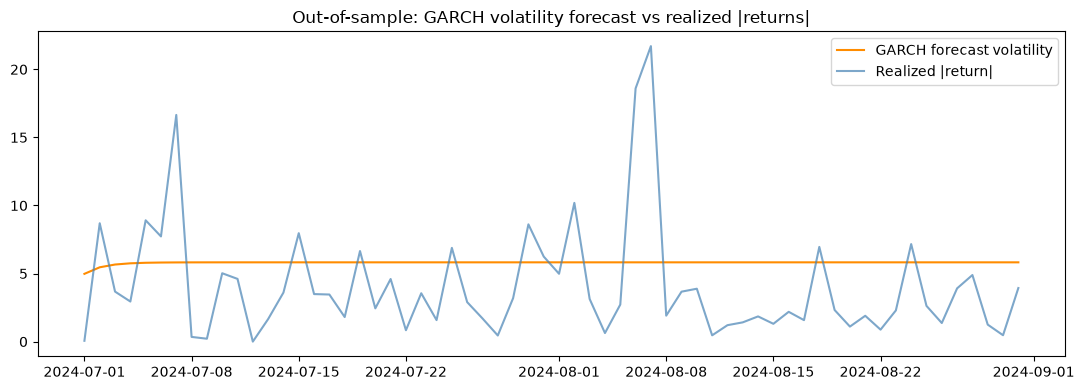

Correlation between forecast volatility and realized |returns|: 0.052


In [6]:
returns_train = returns_pct.loc[:"2024-06-30"]
returns_oos = returns_pct.loc["2024-07-01":"2024-08-31"]  # matches our val window

garch_train = arch_model(returns_train, vol="Garch", p=1, q=1, mean="Constant", dist="normal")
garch_train_fit = garch_train.fit(disp="off")

forecast_result = garch_train_fit.forecast(horizon=len(returns_oos), reindex=False)
forecast_vol = np.sqrt(forecast_result.variance.values[-1])  # predicted daily std dev for each day ahead

realized_vol = returns_oos.abs()  # |return| as a simple realized-volatility proxy

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(returns_oos.index, forecast_vol, label="GARCH forecast volatility", color="darkorange")
ax.plot(returns_oos.index, realized_vol.values, label="Realized |return|", color="steelblue", alpha=0.7)
ax.legend()
ax.set_title("Out-of-sample: GARCH volatility forecast vs realized |returns|")
plt.tight_layout()
plt.show()

corr = np.corrcoef(forecast_vol, realized_vol.values)[0, 1]
print(f"Correlation between forecast volatility and realized |returns|: {corr:.3f}")


**Expanding-window 1-step-ahead GARCH forecasts**

1-step-ahead correlation: 0.213


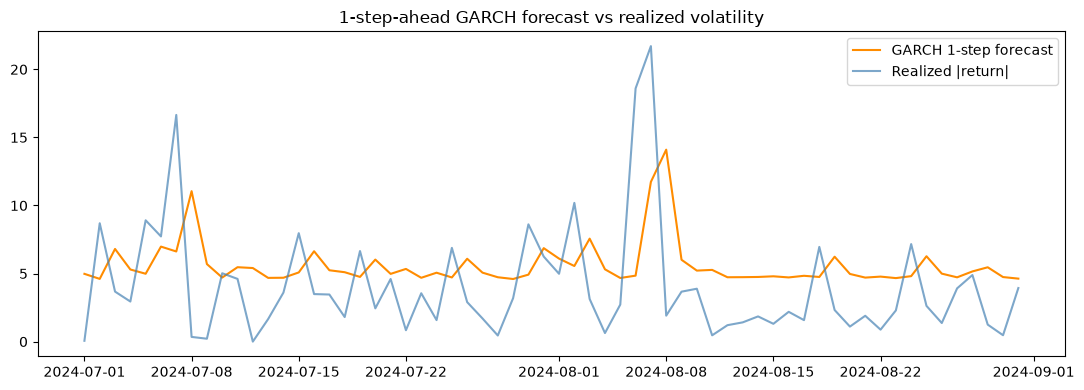

In [7]:
oos_dates = returns_oos.index
one_step_forecasts = []

for date in oos_dates:
    history = returns_pct.loc[:date].iloc[:-1]  # everything strictly before this date
    m = arch_model(history, vol="Garch", p=1, q=1, mean="Constant", dist="normal")
    f = m.fit(disp="off")
    fc = f.forecast(horizon=1, reindex=False)
    one_step_forecasts.append(np.sqrt(fc.variance.values[-1, 0]))

one_step_forecasts = np.array(one_step_forecasts)
realized_vol_oos = returns_oos.abs().values

corr_1step = np.corrcoef(one_step_forecasts, realized_vol_oos)[0, 1]
print(f"1-step-ahead correlation: {corr_1step:.3f}")

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(oos_dates, one_step_forecasts, label="GARCH 1-step forecast", color="darkorange")
ax.plot(oos_dates, realized_vol_oos, label="Realized |return|", color="steelblue", alpha=0.7)
ax.legend()
ax.set_title("1-step-ahead GARCH forecast vs realized volatility")
plt.tight_layout()
plt.show()
